In [2]:
from netCDF4 import Dataset
import datetime
import warnings
import matplotlib
import pandas as pd
import os
import numpy as np
from scipy.signal import argrelextrema
import pickle
from scipy.stats import linregress
import warnings
import matplotlib.pyplot as plt
from scipy.stats import binned_statistic as bs
# import sys
# sys.path.append('/home/robbie/custom_modules/')
from ll_xy import lonlat_to_xy
import kuka_tools as kt
import matplotlib.gridspec as gridspec
import itertools
# You can find kuka_tools at https://github.com/robbiemallett/custom_modules/blob/master/kuka_tools.py

In [3]:
data = pickle.load(open('20206_10_03_wfms','rb'))
freqs=['ku','ka']

nearfardict=pickle.load(open('nearfardict','rb'))



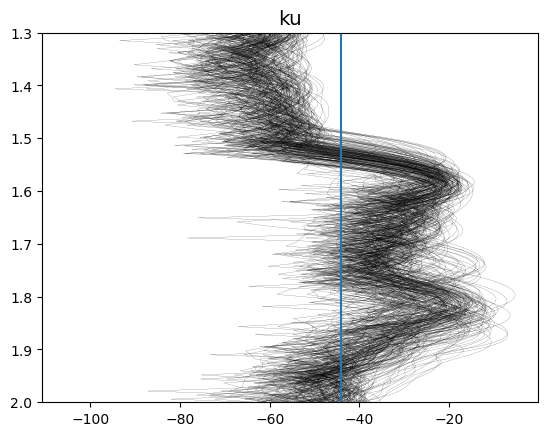

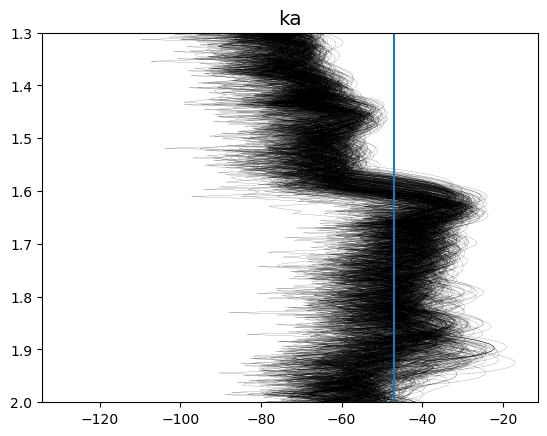

In [4]:
for freq in freqs:
    
    ranges=nearfardict[freq]['range']
    df = data[freq]
    
    for i in range(df.shape[0]):
        d = df.iloc[i]
        power=d['vv']
    
        plt.plot(10*np.log10(power),
             ranges,
             color='k',lw=0.1)
    
    
    plt.ylim(2,1.3)
    # plt.xlim(-10,0)
    if freq =='ka':
        plt.axvline(-47)
    elif freq=='ku':
        plt.axvline(-44)

    plt.title(freq,fontsize='x-large')
    plt.show()

# Analyse peaks

In [5]:
for freq in freqs:
    
    ranges=nearfardict[freq]['range']
    
    df = data[freq]
    
    thresh = -44 if freq =='ku' else -50
    
    npeaks = []
    
    # multi_peak_inds = {x:{} for x in range(1,5)}
    
    shifts=[]
    
    # peak_dfs=[]
    
    for i in range(df.shape[0]):
        
        power = df['vv'].iloc[i]
        
        # Identify all peaks more than 10% of max power
        
        ### Identify the indexes of all local maxima
        
        max_inds = argrelextrema(power, np.greater)[0]
        
        ### Catalogue the characteristics of the local maxima
        
        list_of_dicts_for_df = [{'ind':q,'power':power[q],'range':nearfardict[freq]['range'][q]} for q in max_inds]
        
        ### Sort dataframe so modst powerful peaks at top
        
        peaks_df = pd.DataFrame(list_of_dicts_for_df).sort_values('power',ascending=False)
        
        max_power = peaks_df.iloc[0]['power']
        
        # Calculate power of each peak relative to max power
        # peaks_df['rel_power'] = [x/max_power for x in peaks_df['power']]
        
        # Filter out weak peaks with a threshold to remove sidelobes
        peaks_df = peaks_df[10*np.log10(peaks_df['power'])>thresh]
        
        # Sort peaks into ascending range
        peaks_df = peaks_df.sort_values('range',ascending=True)
    
        # Append the index of the first significant peak to calculate waveform shifts
        shifts.append(peaks_df.iloc[0]['ind'])
        
        # # Log npeaks to main dataframe
        npeaks.append(peaks_df.shape[0])

    df['shifts']=shifts
    df['range_shift']=[ranges[int(x)] if ~np.isnan(x) else np.nan for x in df['shifts'] ]
    df['npeaks']=npeaks
    
    df = df[df['range_shift']<1.73]

    print(df.shape)
    print(ranges.shape)

(225, 16)
(223,)
(457, 16)
(372,)


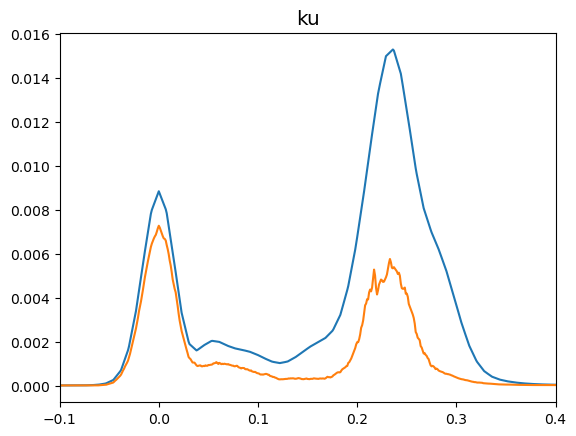

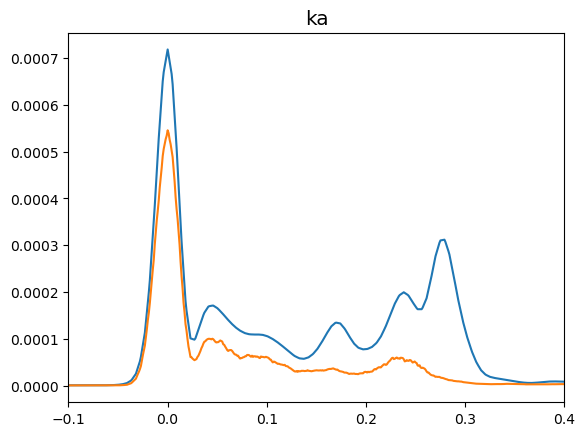

In [6]:
    
yints={'ka':[],'ku':[]}
peak_dfs = {'ku':[],'ka':[]}


for freq in freqs:

    df = data[freq]
    
    ranges=nearfardict[freq]['range']
    
    xinterp = np.arange(-0.1,0.50,0.001)
         

    for i in range(df.shape[0]):
    
        yinterp_vv = np.interp(xinterp,ranges-df['range_shift'].iloc[i],
                 df['vv'].iloc[i])
        
        yinterp_hv = np.interp(xinterp,
                               ranges-df['range_shift'].iloc[i],
                                 df['hv'].iloc[i])
    
    
        ### Identify the indexes of all local maxima
        
        max_inds = argrelextrema(yinterp_vv, np.greater)[0]
        
        ### Catalogue the characteristics of the local maxima
        
        list_of_dicts_for_df = [{'ind':q,
                                 'vv_power':yinterp_vv[q],
                                 'hv_power':yinterp_hv[q],
                                 'range':xinterp[q]} for q in max_inds]
        
        ### Sort dataframe so modst powerful peaks at top
        
        peaks_df = pd.DataFrame(list_of_dicts_for_df).sort_values('vv_power',
                                                                  ascending=False)
        
        max_power = peaks_df.iloc[0]['vv_power']
        
        # Calculate power of each peak relative to max power
        # peaks_df['rel_power'] = [x/max_power for x in peaks_df['power']]
        
        # Filter out weak peaks with a threshold to remove sidelobes
        peaks_df = peaks_df[10*np.log10(peaks_df['vv_power'])>thresh]
        
        # Sort peaks into ascending range
        peaks_df = peaks_df.sort_values('range',ascending=True)
    
        # peaks_df = peaks_df[peaks_df['range']<0.12]
    
        peak_dfs[freq].append(peaks_df)
    
        if peaks_df.shape[0]>1:
    
            yints[freq].append(yinterp_vv)
    
    
    ymean = np.nanmean(yints[freq],axis=0)
    plt.plot(xinterp,ymean)
    
    # if freq=='ku':pickle.dump(ymean,open('Figure3/roth_waveform.p','wb'))
    
    ymedian = np.nanmedian(yints[freq],axis=0)
    plt.plot(xinterp,ymedian)
    # plt.ylim(0,0.0002)
    
    plt.title(freq,fontsize='x-large')
    plt.xlim(-0.1,0.4)
    plt.show()

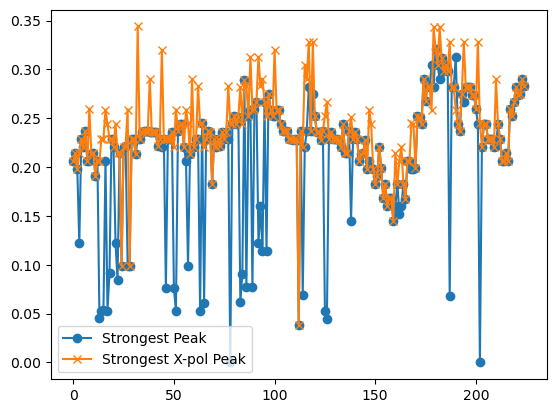

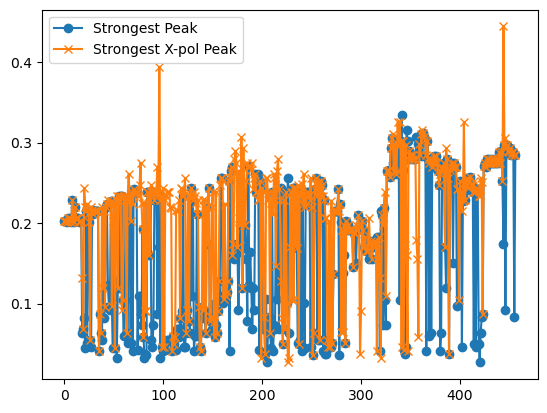

In [7]:
for freq in freqs:

    df = data[freq]
    
    counts_valid=[]
    
    r_rmaxs_valid=[]
    p_rmaxs=[]
    
    r_xmaxs_valid=[]
    p_xmaxs=[]
    
    r_amaxs_valid=[]
    p_amaxs=[]
    
    r_nearests=[]
    p_nearests=[]
    
    magna=[]
    
    p0=[]
    
    for count,peak_df in enumerate(peak_dfs[freq]):
    
        if peak_df.shape[0]>1:
    
            # magna_depth = float(df.iloc[count]['magna_depths']/100)
    
            # Calculate index of maximum power below the snow
            amax=np.argmax(peak_df.iloc[1:]['vv_power'])
            # Calculate range of peak with max power
            r_amax = peak_df.iloc[1:].iloc[amax]['range']
            # Calculate power of peak with max power
            a_amax = peak_df.iloc[1:].iloc[amax]['vv_power']        
            
            # Calculate range of furthest peak in range
            r_rmax = peak_df.iloc[-1]['range']
            a_rmax = peak_df.iloc[-1]['vv_power']
    
            # Calculate index of strongest x-pol power below the snow
            xmax=np.argmax(peak_df.iloc[1:]['hv_power'])
            # Calculate range of peak with max power
            r_xmax = peak_df.iloc[1:].iloc[xmax]['range']
            a_xmax = peak_df.iloc[1:].iloc[xmax]['vv_power']
    
    
            counts_valid.append(count)
            r_rmaxs_valid.append(r_rmax)
            r_amaxs_valid.append(r_amax)
            r_xmaxs_valid.append(r_xmax)
    
            p_rmaxs.append(a_rmax)
            p_amaxs.append(a_amax)
            p_xmaxs.append(a_xmax)
            
            p0.append(peak_df.iloc[0]['vv_power'])

        else:

            counts_valid.append(count)
            r_rmaxs_valid.append(np.nan)
            r_amaxs_valid.append(np.nan)
            r_xmaxs_valid.append(np.nan)
    
            p_rmaxs.append(np.nan)
            p_amaxs.append(np.nan)
            p_xmaxs.append(np.nan)
            
            p0.append(peak_df.iloc[0]['vv_power'])
            

            
    
            
        
    # plt.plot(counts_valid,r_rmaxs_valid,label='Furthest Peak',marker='.')
    plt.plot(counts_valid,r_amaxs_valid,label='Strongest Peak',marker='o')
    plt.plot(counts_valid,r_xmaxs_valid,label='Strongest X-pol Peak',marker='x')
    # plt.plot(counts_valid,r_nearests,label='Nearest to Magna',marker='.')
    # plt.plot(counts_valid,magna,label='Magna',marker='.')
    plt.legend()
    plt.show()

    
    df['p0']=p0
    df['p_rmax']=p_rmaxs
    df['p_amax']=p_amaxs
    df['p_xmax']=p_xmaxs
    df['r_rmax']=r_rmaxs_valid
    df['r_amax']=r_amaxs_valid
    df['r_xmax']=r_xmaxs_valid

    products=['xmax','rmax','pmax','p0']
    ps=[p_xmaxs,p_rmaxs,p_amaxs,p0]
    
    powers={q:m for q,m in zip(products,ps)}
    pickle.dump(powers,open(f'/home/robbie/Dropbox/kuka_slush/code/ice_powers/03_{freq}_flood.p','wb'))

    # pickle.dump(df,open(f'/home/robbie/Dropbox/kuka_slush/code/ice_powers/{freq}_full_df.p','wb'))

    df.reset_index(inplace=True)
    
    if freq=='ka':
    
        df = df[df.index<410]
    
        df = df[df.index>25]
    ranges=nearfardict[freq]['range']
    pickle.dump((ranges,df),open(f'03_{freq}.p','wb'))


In [8]:
diffs=np.array(data['ku']['r_xmax']-data['ku']['r_amax'])
q=diffs[diffs==0]
len(q),len(diffs),len(q)/len(diffs)


(166, 225, 0.7377777777777778)

In [9]:
ranges=nearfardict[freq]['range']

nearfardict['ku']['range'].shape

(223,)

In [10]:
freqs=['ku','ka']
dfs={}
ranges_dict = {}
for freq in freqs:
    ranges=nearfardict[freq]['range']
    ranges,df = pickle.load(open(f'03_{freq}.p','rb'))
    dfs[freq]= df
    ranges_dict[freq]=ranges

0.00010172526041696273 0.019454274549993298
0.0025272369384767845 0.028614957736635097


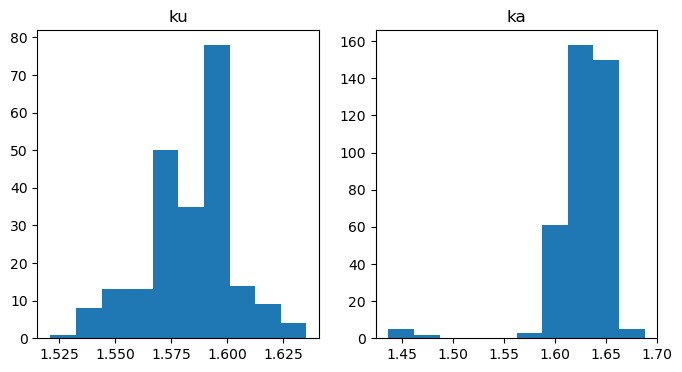

In [11]:
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(8,4))

for freq,ax in zip(freqs,[ax1,ax2]):
    df=dfs[freq]
    ax.hist(df['range_shift'])
    ax.set_title(freq)
    q=df['range_shift']-np.nanmean(df['range_shift'])
    print(np.nanmedian(q),np.nanstd(q))

plt.show()

In [12]:
for freq in freqs:
    df=dfs[freq]
    df.to_csv(f'index_chasing_03_tmp_{freq}.csv')

In [14]:
dfs['ku']['lo

Index(['index', 'vv', 'hv', 'vh', 'hh', 'corr', 'speed', 'along_track', 'time',
       'x', 'y', 'xtilt', 'atilt', 'code', 'shifts', 'range_shift', 'npeaks',
       'p0', 'p_rmax', 'p_amax', 'p_xmax', 'r_rmax', 'r_amax', 'r_xmax'],
      dtype='object')

In [14]:
pit_indices_raw = {}
pit_indices={}

pit_indices_raw['ku']=  [161, 256, 336, 424, 525, 624, 66]
pit_indices['ku']=[8,48,84,118,145,184,213]

pit_indices_raw['ka'] = [232, 417, 560, 707, 877, 1081, 70]
pit_indices['ka'] = np.array([16, 93, 164,213, 270,355,411])

In [15]:
echograms={}
echograms_hv={}
at_valids={}
s_ranges = {}

for freq in freqs:
    
    df=dfs[freq]
    
    ranges=nearfardict[freq]['range']
    
    if freq=='ku':
        n=72
    elif freq=='ka':
        n=120
        
    echogram=np.full((df.shape[0],n),np.nan)
    echogram=[]
    echogram_hv=[]
    at_valid=[]
    for i in range(df.shape[0]):
        d = df.iloc[i]
        power=d['vv']
        power_hv=d['hv']
        along_track=d['along_track']
        shift=d['shifts']
    
        if np.isnan(shift):
            echogram.append([np.nan]*n)
    
        else:
            
            shift=int(shift)
            
            shifted_ranges = ranges-ranges[shift]
            
            power_in_range = power[(shifted_ranges>-0.1)&(shifted_ranges<0.45)]
            power_in_range_hv = power_hv[(shifted_ranges>-0.1)&(shifted_ranges<0.45)]
            if i==0:
                print(power_in_range.shape)
            if power_in_range.shape[0]==n:
                echogram.append(power_in_range)
                echogram_hv.append(power_in_range_hv)
                at_valid.append(along_track)
    
    echograms[freq]=np.array(echogram)
    echograms_hv[freq]=np.array(echogram_hv)
    at_valids[freq]=np.array(at_valid)
    s_ranges[freq]=shifted_ranges
    

(72,)
(120,)


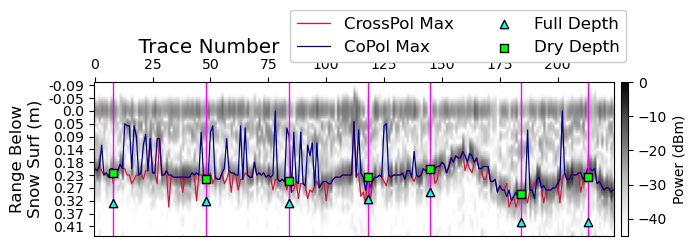

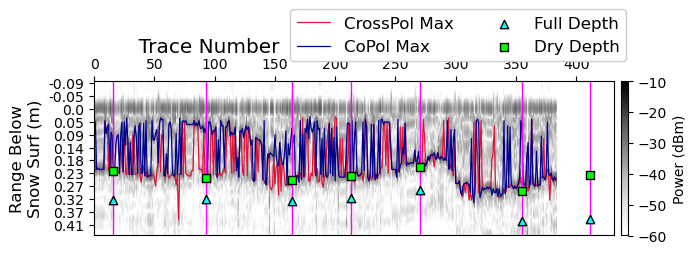

In [16]:
def make_echogram(ax,freq,leg_pad=1.2,pol='vv'):
    
    df=dfs[freq]
    ranges=ranges_dict[freq]
    
    if pol=='vv':echogram=echograms[freq]
    elif pol=='hv':echogram=echograms_hv[freq]
    shifted_ranges=s_ranges[freq]
    
    if freq=='ku':
        if pol=='vv':
            vmin=-45
            vmax=0
        elif pol=='hv':
            vmin=-70
            vmax=-30
        n=72
    elif freq=='ka':
        vmin=-60
        vmax=-10
        n=120

    im=ax.imshow(10*np.log10(echogram.T),vmin=vmin,vmax=vmax,
                 # cmap='afmhot',
                 cmap='Greys',
                 aspect='auto')
    

    yaxis = shifted_ranges[(shifted_ranges>-0.1)&(shifted_ranges<0.45)]
    

    
    y_snow_depth_ind=[]
    y_wet_depth_ind=[]
    for ssd,swd in zip(scaled_snow_depths,scaled_dry_depths):
        #find index of closest shifted range bin to snow depth
        y_snow_depth_ind.append(np.argmin(np.abs(yaxis-ssd)))
        y_wet_depth_ind.append(np.argmin(np.abs(yaxis-swd)))

    r_xmax_ind=[]
    r_amax_ind=[]
    for rx,ra in zip(df['r_xmax'],df['r_amax']):
        r_xmax_ind.append(np.argmin(np.abs(yaxis-rx)))
        r_amax_ind.append(np.argmin(np.abs(yaxis-ra)))

    ax.plot(r_xmax_ind,color='crimson',label='CrossPol Max',lw=0.9)
    ax.plot(r_amax_ind,color='darkblue',label='CoPol Max',lw=0.9)
    
    # y_wet_depth_ind[0]=np.nan
    for i in pit_indices[freq]:
        ax.axvline(i,color='magenta',lw=1)
    ax.scatter(pit_indices[freq],y_snow_depth_ind,zorder=1000,marker='^',color='cyan',label='Full Depth',edgecolor='k')
    ax.scatter(pit_indices[freq],y_wet_depth_ind,zorder=1000,marker='s',color='lime',label='Dry Depth',edgecolor='k')
    ax.legend(loc='center',bbox_to_anchor=(0.7,leg_pad),ncols=2,fontsize='large',framealpha=1)
    ax.set_xlabel('       Trace Number',fontsize='x-large',loc='left')
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position('top')
    tickspace=6 if freq=='ku' else 10
    yticks=np.arange(1,n,tickspace)
    ylabs=[np.round(yaxis[x],decimals=2) for x in yticks]
    ax.set_yticks(yticks,labels=ylabs)
    ax.set_ylabel('Range Below\nSnow Surf (m)',fontsize='large')
    cb=fig.colorbar(im,shrink=1,pad=0.01)
    cb.set_label('Power (dBm)')
    
    data_dict[freq]['yaxis']=yaxis

data_dict = {'ka':{},'ku':{}}

snow_depths=np.array([24,24.5,25,24,21.5,30,28])/100
wet_depths=np.array([5.5,4,4,4,4.5,5.5,8.5])/100

dry_scale_factor=1.2
wet_scale_factor=1.9
scaled_snow_depths = (snow_depths-wet_depths)*dry_scale_factor + (wet_depths*wet_scale_factor)
scaled_dry_depths = (snow_depths-wet_depths)*dry_scale_factor
    
for freq in freqs:
    
    fig,ax = plt.subplots(1,1,figsize=(8,2))

    
    make_echogram(ax,freq=freq,leg_pad=1.3,pol='vv')
    
    plt.show()


In [1]:
df

NameError: name 'df' is not defined

roth02 100.0 100.0
roth03 105.0473777902468 107.81021366674727
mosa_east 54.14324657388277 54.094829235081114
roth23 4.083045496458187 4.0134710076034175
res_1 12.253620603986969 13.967758443073954
res_2 10.219591911082437 10.273380546642233
res_3 22.773976771315237 22.261417917728824
chch_1 7.921978780060233 10.782612679750459
chch_2 9.580467157157015 10.461161110355796
mosa_west 8.958813769667298 11.776464993212178


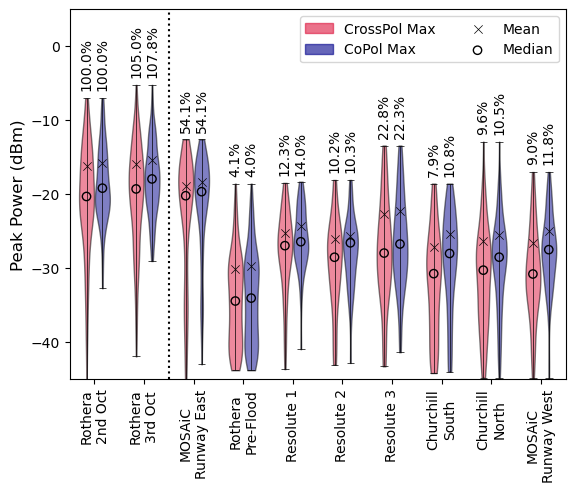

In [28]:

def make_violins(ax):

    sites = ['Rothera\n2nd Oct',
         'Rothera\n3rd Oct',
         'MOSAiC\nRunway East',
         'Rothera\nPre-Flood',
         'Resolute 1',
         'Resolute 2',
         'Resolute 3',
         'Churchill\nSouth',
         'Churchill\nNorth',
         'MOSAiC\nRunway West',]


    colors=['r','b','g','purple','orange','cyan']    
    # Produced by Dropbox/kuka_slush/code/2_HC_20261002
    roth_powers02 = pickle.load(open('/home/robbie/Dropbox/kuka_slush/code/ice_powers/02_ku_flood.p','rb'))
    # Produced by Dropbox/kuka_slush/code/2_HC_20261003
    roth_powers03 = pickle.load(open('/home/robbie/Dropbox/kuka_slush/code/ice_powers/03_ku_flood.p','rb'))
    # Produced by Dropbox/kuka_slush/code/HC_20260903
    roth0_powers = pickle.load(open('/home/robbie/Dropbox/kuka_slush/code/ice_powers/roth0_power.p','rb'))
    #Dropbox/kuka_resolute/analyse_waveforms.ipynb
    reso_powers_1 = pickle.load(open('/home/robbie/Dropbox/kuka_slush/code/ice_powers/res_power_1.p','rb'))
    reso_powers_2 = pickle.load(open('/home/robbie/Dropbox/kuka_slush/code/ice_powers/res_power_2.p','rb'))
    reso_powers_3 = pickle.load(open('/home/robbie/Dropbox/kuka_slush/code/ice_powers/res_power_3.p','rb'))
    #/Dropbox/kuka_churchill/2_process_wfms.ipynb
    chch_powers_1 = pickle.load(open('/home/robbie/Dropbox/kuka_slush/code/ice_powers/chch_power_1.p','rb'))
    chch_powers_2 = pickle.load(open('/home/robbie/Dropbox/kuka_slush/code/ice_powers/chch_power_2.p','rb'))
    #Dropbox/kuka_mosaic/3_get_radar_depths.ipynb
    mosa_powers_east = pickle.load(open('/home/robbie/Dropbox/kuka_slush/code/ice_powers/mosa_power_2.p','rb'))
    mosa_powers_west = pickle.load(open('/home/robbie/Dropbox/kuka_slush/code/ice_powers/mosa_power_1.p','rb'))
    
    pdict = {'roth02':roth_powers02,
             'roth03':roth_powers03,
             'mosa_east':mosa_powers_east,
             'roth23':roth0_powers,
             'res_1':reso_powers_1,
             'res_2':reso_powers_2,
             'res_3':reso_powers_3,
             'chch_1':chch_powers_1,
             'chch_2':chch_powers_2,
             'mosa_west':mosa_powers_west,
             }
    roth_mean_x = np.nanmean(pdict['roth02']['xmax'])
    roth_mean_p = np.nanmean(pdict['roth02']['pmax'])
    
    percentages = {}
    
    for counter,(k, v) in enumerate(list(pdict.items())):
    
        keys = v.keys()
    
        powers = []    
        
        for key in ['xmax','pmax']:
    
            powers.append(v[key])
    
        mean_xmax = 100*np.nanmean(powers[0])/roth_mean_x
        mean_pmax = 100*np.nanmean(powers[1])/roth_mean_p
    
        percentages[k]=(mean_xmax,mean_pmax)
    
        print(k,mean_xmax,mean_pmax)

    
    for counter,(k, v) in enumerate(list(pdict.items())):
    
        keys = v.keys()
    
        powers = []    
        
        for key in ['xmax','pmax']:
    
            powers.append(v[key])
    
        log_powers= [10*np.log10(powers[0]),
                     10*np.log10(powers[1])]
    
    
        violin_parts = plt.violinplot(log_powers,
                                      positions=counter+np.array([-0.16,0.16]),
                                      widths=0.3)
    
        if k !='roth':
            ax.annotate(text=f'{np.round(percentages[k][0],decimals=1)}%',xy=(counter-0.16,1+np.max(log_powers[0])),
                        xycoords='data',rotation=90,va='bottom',
                        ha='center')
            ax.annotate(text=f'{np.round(percentages[k][1],decimals=1)}%',xy=(counter+0.16,1+np.max(log_powers[0])),
                        xycoords='data',rotation=90,va='bottom',
                        ha='center')
    
        mean = np.nanmean(powers,axis=1)
        mean = 10*np.log10(mean)
        
        ax.scatter(counter+np.array([-0.16,0.16]),
                                     mean,
                    color='k',marker='x',linewidths=0.5)
    
        median = np.nanmedian(powers,axis=1)
        median = 10*np.log10(median)
        
        ax.scatter(counter+np.array([-0.16,0.16]),
                    median,marker='o',
                   facecolors='none', edgecolors='k',zorder=100)
    
        # Make the violin body blue with a red border:
        vp=violin_parts['bodies'][0]
        vp.set_facecolor('crimson')
        vp=violin_parts['bodies'][1]
        vp.set_facecolor('darkblue')
        
        for vp in violin_parts['bodies']:
    
            vp.set_edgecolor('k')
            vp.set_linewidth(1)
            vp.set_alpha(0.5)
    
        cb=violin_parts['cbars']
        
        cb.set_edgecolor('k')
        cb.set_linewidth(0.5)
        cb.set_colors('k')
        cm=violin_parts['cmaxes']
        cm.set_linewidth(0.5)
        cm.set_color('k')
        cm=violin_parts['cmins']
        cm.set_linewidth(0.5)
        cm.set_color('k')
    
    
    ax.fill_betweenx(x1=-10,x2=-9,y=[5,6,7],label='CrossPol Max',color='crimson',alpha=0.6)
    ax.fill_betweenx(x1=-10,x2=-9,y=[5,6,7],label='CoPol Max',color='darkblue',alpha=0.6)
    ax.scatter([],[],color='k',marker='x',linewidths=0.5,label='Mean')
    ax.scatter([],[],marker='o',facecolors='none', edgecolors='k',zorder=100,label='Median')
    ax.legend(ncols=2)
    
    ax.set_xticks(np.arange(len(sites)),labels=sites,rotation=90)
    
    ax.set_ylabel('Peak Power (dBm)',fontsize='large')
    
    # plt.ylim(0,0.2)
    ax.set_ylim(-45,5)
    
    ax.set_xlim(-0.5,len(sites)-0.5)
    
    ax.axvline(1.5,color='k',ls=':')

    
fig,ax=plt.subplots(1,1)

make_violins(ax)


plt.show()

roth02 100.0 100.0
roth03 105.0473777902468 107.81021366674727
mosa_east 54.14324657388277 54.094829235081114
roth23 4.083045496458187 4.0134710076034175
res_1 12.253620603986969 13.967758443073954
res_2 10.219591911082437 10.273380546642233
res_3 22.773976771315237 22.261417917728824
chch_1 7.921978780060233 10.782612679750459
chch_2 9.580467157157015 10.461161110355796
mosa_west 8.958813769667298 11.776464993212178


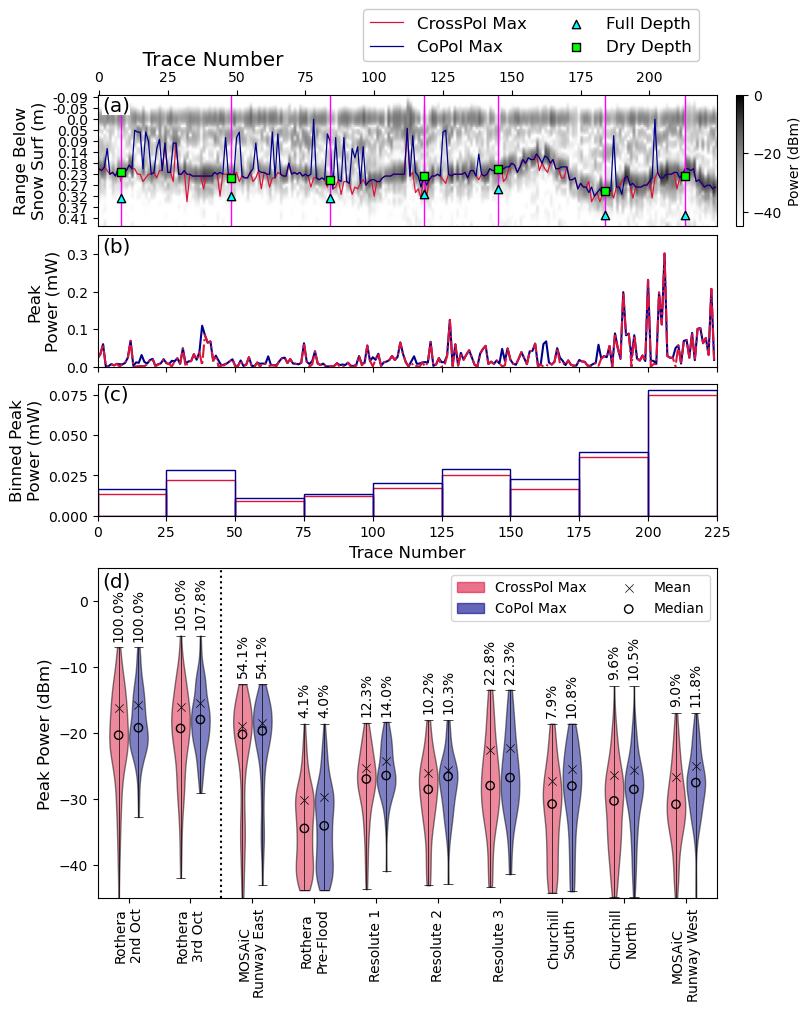

In [29]:
fig,(ax1,ax2,ax3,ax4)=plt.subplots(4,1,figsize=(8,10),constrained_layout=True,height_ratios=[1,1,1,2.5])

make_echogram(ax1,freq='ku',leg_pad=1.45,pol='vv')

df=dfs['ku']
ax2.plot(df['p_amax'],color='darkblue')
ax2.plot(df['p_xmax'],ls='-.',color='crimson')
ax2.set_xlim(0,df.shape[0])
ax2.set_ylim(0,0.35)
ax2.set_xticklabels([])
ax2.set_ylabel('Peak\nPower (mW)',fontsize='large')

q=bs(np.arange(df.shape[0]),df['p_xmax'],bins=np.arange(0,226,25))
ax3.bar(12.5+np.arange(0,225,25),list(q.statistic),width=25,facecolor='none',edgecolor='crimson')

q=bs(np.arange(df.shape[0]),df['p_amax'],bins=np.arange(0,226,25))
ax3.bar(12.5+np.arange(0,225,25),list(q.statistic),width=25,facecolor='none',edgecolor='darkblue')

ax3.set_xlim(0,df.shape[0])

ax3.set_ylabel('Binned Peak\nPower (mW)',fontsize='large')
ax3.set_xlabel('Trace Number',fontsize='large')

make_violins(ax4)

import string
letters = string.ascii_lowercase
for ax,letter in zip([ax1,ax2,ax3,ax4],letters):

    xcoord=0.007
    ax.annotate(f'({letter})',
                fontsize='x-large',
                xy=(xcoord,0.99),va='top',xycoords='axes fraction',
               bbox=dict(facecolor='white', edgecolor='none',pad=0))

fig.get_layout_engine().set(hspace=0)

ddir = '/home/robbie/Dropbox/Apps/Overleaf/Rothera_flooding/figures/'

plt.savefig(f'{ddir}Fig3.png',dpi=500,bbox_inches='tight')

In [ ]:
fig,(ax1,ax2)=plt.subplots(2,1,figsize=(8,5))

plt.scatter(1.5*df['along_track'],df['p_xmax'])


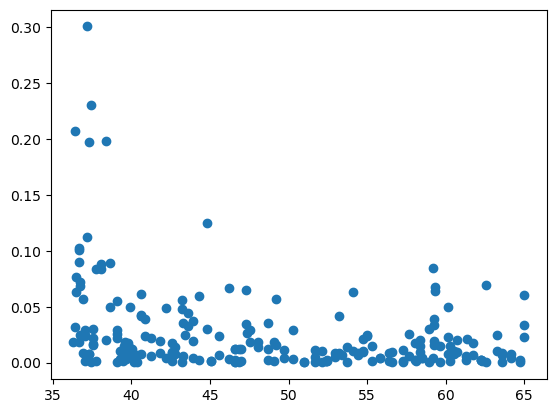

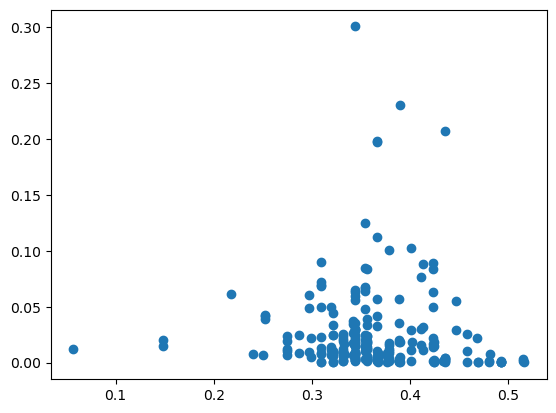

In [29]:
df=dfs['ku']
plt.scatter(1.5*df['along_track'],df['p_xmax'])
plt.show()
linregress(1.5*df['along_track'],df['p_xmax'])
plt.scatter(1.5*df['r_xmax'],df['p_xmax'])

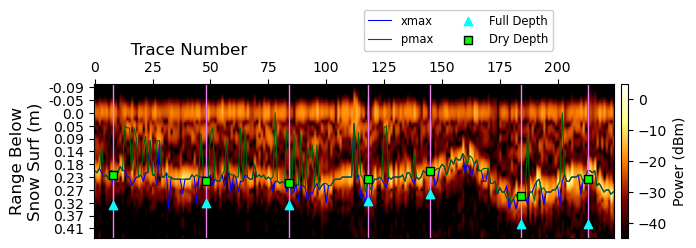

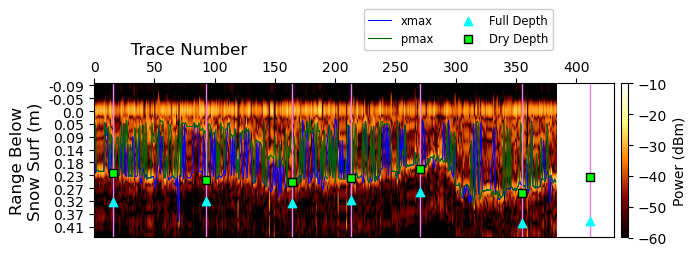

In [47]:
data_dict = {'ka':{},'ku':{}}
    
for freq in freqs:
    
    fig,ax = plt.subplots(1,1,figsize=(8,2))

    
    make_echogram(ax,freq=freq,leg_pad=1.35,pol='vv')

    
    
    plt.show()


In [48]:
pickle.dump(data_dict,open('data_dict.p','wb'))
pickle.dump(dfs,open('data_dict.p','wb'))

In [65]:
i

np.int64(411)

In [66]:
dfs['ka']['along_track']

0      40.975493
1      40.619287
2      40.619287
3      40.619287
4      40.619287
         ...    
379    24.472799
380    24.472799
381    24.472799
382    24.392126
383    24.392126
Name: along_track, Length: 384, dtype: float64

In [67]:
for freq in freqs[:1]:
    
    if freq=='ku':
        n=72
    elif freq=='ka':
        n=120

    
    df=dfs[freq]
    try:
        df.reset_index(inplace=True)
    except: pass
    
    ranges=ranges_dict[freq]
    shifted_ranges=s_ranges[freq]
    yaxis=data_dict[freq]['yaxis']

    thresh=0.1 if freq=='ku' else 0.2
        
    newx = yaxis[yaxis>thresh]
    
    radar_scat=[]
    mean_wfms=[]

    for i,ssd,swd in zip(pit_indices[freq],scaled_snow_depths,scaled_dry_depths):

        along_track = df['along_track'].iloc[i]

        arg_start = np.argmin(np.abs(df['along_track']-along_track-1))

        arg_end = np.argmin(np.abs(df['along_track']-along_track+1))

        print(i,arg_start,arg_end,arg_start-arg_end)

        

    print()

8 0 15 -15
48 32 59 -27
84 76 92 -16
118 105 125 -20
145 129 152 -23
184 158 196 -38
213 190 224 -34



In [77]:
for freq in freqs[:1]:
    
    if freq=='ku':
        n=72
    elif freq=='ka':
        n=120

    
    df=dfs[freq]
    ranges=nearfardict[freq]['range']
    shifted_ranges=s_ranges[freq]
    yaxis=data_dict[freq]['yaxis']

    thresh=0.1 if freq=='ku' else 0.2
        
    newx = yaxis[yaxis>thresh]
    
    radar_scat=[]
    mean_wfms=[]

    for i,ssd,swd in zip(pit_indices[freq],scaled_snow_depths,scaled_dry_depths):
    
        window=10
        wfms=[]

        along_track = df['along_track'].iloc[i]
        arg_start = np.argmin(np.abs(df['along_track']-along_track-1))
        arg_end = np.argmin(np.abs(df['along_track']-along_track+1))
        print(arg_start,arg_end)
        for r in np.arange(arg_start,arg_end):
            
            d = df.iloc[r]
            power=d['vv']
            shift=int(d['shifts'])
            shifted_ranges = ranges-ranges[shift]
            power_in_range = power[(shifted_ranges>-0.1)&(shifted_ranges<0.45)]
            if i==0:
                print(power_in_range.shape)
            if power_in_range.shape[0]==n:
                wfms.append(power_in_range)
    
    
        mean_wfm=np.nanmean(wfms,axis=0)
        mean_wfms.append(mean_wfm)
        newy=mean_wfm[yaxis>thresh]
        x_max=newx[np.argmax(newy)]
        radar_scat.append(x_max)

    data_dict[freq]['mean_wfms']=mean_wfms
    data_dict[freq]['radar_scats']=radar_scat
    print(radar_scat)
    print('done')

0 15
32 59
76 92
105 125
129 152
158 196
190 224
[np.float64(0.20599365234375), np.float64(0.23651123046875), np.float64(0.244140625), np.float64(0.2288818359375), np.float64(0.22125244140625), np.float64(0.28228759765625), np.float64(0.244140625)]
done


148.00272767075003
[np.float64(0.20599365234375), np.float64(0.23651123046875), np.float64(0.244140625), np.float64(0.2288818359375), np.float64(0.22125244140625), np.float64(0.28228759765625), np.float64(0.244140625)]


/tmp/ipykernel_145047/3202392217.py:81: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(hspace=[0.1,0.5,0.2])
/tmp/ipykernel_145047/3202392217.py:85: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  plt.savefig(f'{over_dir}/F2.png',dpi=500,bbox_inches='tight')
/home/robbie/anaconda3/envs/flood/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


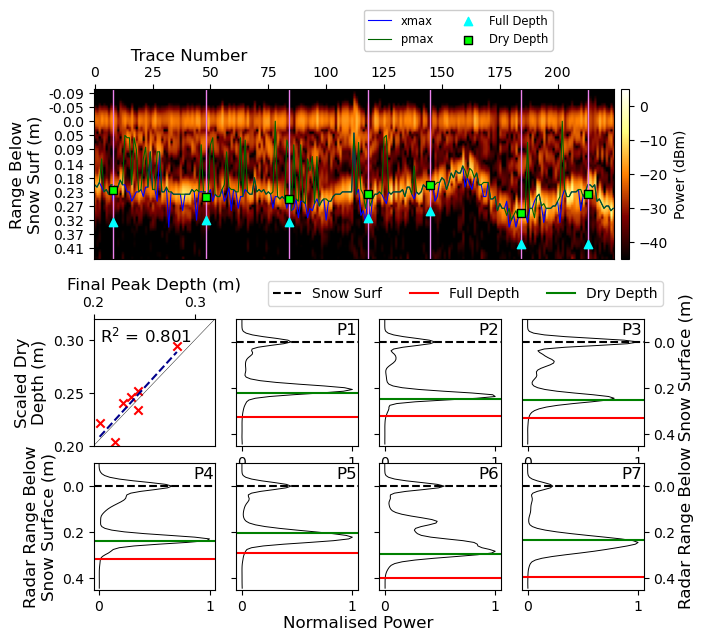

In [81]:
for freq in freqs[:1]:
    if freq=='ku':
        n=72
    elif freq=='ka':
        n=120
        
    yaxis=data_dict[freq]['yaxis']
    mean_wfms=data_dict[freq]['mean_wfms']
    radar_scat=data_dict[freq]['radar_scats']
        
    fig=plt.figure(constrained_layout=True,figsize=(8,6.5))
    gs = fig.add_gridspec(ncols=5, nrows=5,height_ratios=[0.5,0.7,0.2,1,1],width_ratios=[1,1,1,1,0.4])
    ax = fig.add_subplot(gs[0:2, :])
    
    make_echogram(ax,freq=freq,leg_pad=1.35)
    axs=[]
    for i,j in itertools.product(range(3,5),range(0,4)):
        axs.append(fig.add_subplot(gs[i,j]))

    
    ratios=[]
    for mean_wfm,ssd,swd,ax,count in zip(mean_wfms,scaled_snow_depths,scaled_dry_depths,axs[1:],range(1,8)):
        ax.plot(mean_wfm/np.max(mean_wfm),yaxis,color='k',lw=0.7)
        ax.axhline(0,color='k',ls='--',label='Snow Surf')
        ax.axhline(ssd,color='r',label='Full Depth')
        ax.axhline(swd,color='g',label='Dry Depth')
        ax.set_ylim(0.45,-0.1)
        ax.annotate(text=f'P{count}',
                    xy=(0.99,0.97),ha='right',va='top',
                    xycoords='axes fraction',fontsize='large')

        power_dry = mean_wfm[np.argmin(np.abs(yaxis-ssd))]
        power_wet = mean_wfm[np.argmin(np.abs(yaxis-swd))]
        ratios.append(power_wet/power_dry)

    print(np.nanmean(ratios))

    
    ax1=axs[0]
    
    ax1.scatter(radar_scat,scaled_dry_depths,color='r',marker='x')
    print(radar_scat)
    lr = linregress(radar_scat,scaled_dry_depths)
    
    ax1.plot([np.min(radar_scat),np.max(radar_scat)],
             [np.min(radar_scat)*lr[0]+lr[1], np.max(radar_scat)*lr[0]+lr[1]],
             ls='--',color='darkblue')
    
    ax1.set_xlabel('Final Peak Depth (m)',fontsize='large')
    ax1.set_ylabel('Scaled Dry\nDepth (m)',fontsize='large')
    ax1.xaxis.set_label_position('top')
    ax1.xaxis.tick_top()
    
    ax1.set_xlim(0.2,0.32)
    ax1.set_ylim(0.2,0.32)
    ax1.plot([0.2,0.32],[0.2,0.32],color='k',lw=0.3)
    ax1.annotate(text=f'R$^2$ = {np.round(lr[2]**2,decimals=3)}',xy=(0.05,0.95),va='top',xycoords='axes fraction',fontsize='large')

    axst = (x for x in axs)
    ax1,ax2,ax3,ax4,ax5,ax6,ax7,ax8=axst

    for ax in [ax2,ax3,ax6,ax7]:
        ax.set_yticklabels([])
    for ax in [ax4,ax8]:
        ax.yaxis.tick_right()
        ax.yaxis.set_label_position('right')

    
    ax5.set_ylabel('Radar Range Below\nSnow Surface (m)',fontsize='large')

    ax8.annotate(text='Radar Range Below Snow Surface (m)',
                 fontsize='large',xy=(1.35,1.1),ha='center',va='center',
                xycoords='axes fraction',rotation=90)

    
    ax6.annotate(text='Normalised Power',fontsize='large',xy=(1,-0.3),ha='center',
                xycoords='axes fraction')

    ax2.legend(bbox_to_anchor=(0.2,1.2),ncols=3,loc='center left')

    fig.subplots_adjust(hspace=[0.1,0.5,0.2])

    if freq=='ku':
        over_dir = '/home/robbie/Dropbox/Apps/Overleaf/Rothera_flooding/figures/'
        plt.savefig(f'{over_dir}/F2.png',dpi=500,bbox_inches='tight')
    else:
        over_dir = '/home/robbie/Dropbox/Apps/Overleaf/Rothera_flooding/SuppFigs/'
        plt.savefig(f'{over_dir}/Ka_echogram.png',dpi=500,bbox_inches='tight')
    
    plt.show()